## draw_beamline > driftTransformScatter

In [34]:
import os,sys
from pprint import pprint

import torch
from sympy.physics.units import length

pprint(sys.path)

current_dir = os.path.abspath(os.getcwd())

project_root = os.path.abspath(os.path.join(current_dir, '../backend'))

if project_root not in sys.path:
    sys.path.insert(0, project_root)
pprint(sys.path)

['C:\\Users\\yi_lu\\my_files\\research\\FELsim\\backend',
 'C:\\Users\\yi_lu\\my_files\\research\\FELsim',
 'C:\\Users\\yi_lu\\programming_IDE\\PyCharm_2025.2.1\\plugins\\python-ce\\helpers\\pydev',
 'C:\\Users\\yi_lu\\programming_IDE\\PyCharm_2025.2.1\\plugins\\python-ce\\helpers\\jupyter_debug',
 'C:\\Users\\yi_lu\\programming_lang\\Anaconda\\envs\\felsim\\python311.zip',
 'C:\\Users\\yi_lu\\programming_lang\\Anaconda\\envs\\felsim\\DLLs',
 'C:\\Users\\yi_lu\\programming_lang\\Anaconda\\envs\\felsim\\Lib',
 'C:\\Users\\yi_lu\\programming_lang\\Anaconda\\envs\\felsim',
 '',
 'C:\\Users\\yi_lu\\AppData\\Roaming\\Python\\Python311\\site-packages',
 'C:\\Users\\yi_lu\\programming_lang\\Anaconda\\envs\\felsim\\Lib\\site-packages']
['C:\\Users\\yi_lu\\my_files\\research\\FELsim\\backend',
 'C:\\Users\\yi_lu\\my_files\\research\\FELsim',
 'C:\\Users\\yi_lu\\programming_IDE\\PyCharm_2025.2.1\\plugins\\python-ce\\helpers\\pydev',
 'C:\\Users\\yi_lu\\programming_IDE\\PyCharm_2025.2.1\\plugins\

In [35]:
from beamline import *
from ebeam import beam

In [36]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.widgets import Slider
from matplotlib.transforms import Bbox
from matplotlib.widgets import TextBox
import pandas as pd
import csv
import numpy as np
from beamline import *
from ebeam import beam
import datetime
from tqdm import tqdm
from matplotlib.widgets import Button

In [37]:
# before change
class draw_beamline:
    ...
    def driftTransformScatter(self, values, length, plot = True):
        '''
        Simulates particles passing through drift space

        Parameters
        ----------
        values: np.array(list[float][float])
            2D numPy list of particle elements
        length: float
            length of the drift space particle passes through
        plot: bool, optional
            tells function whether to plot particle data or not

        Returns
        -------
        x_transform: list[float]
            list containing each particles' x position
        y_transform: list[float]
            list containing each particles' y position
        '''
        x_pos = values[:, 0]
        phase_x = values[:, 1]
        y_pos = values[:, 2]
        phase_y = values[:, 3]
        x_transform = []
        y_transform = []

        for i in range(len(x_pos)):
            x_transform.append(x_pos[i]+length*phase_x[i])
        for i in range(len(y_pos)):
            y_transform.append(y_pos[i] + length*phase_y[i])

        if plot:
            fig, ax = plt.subplots()
            ax.scatter(x_pos,y_pos, c = 'blue', s=15, alpha=0.7, label = "Initial values")
            ax.scatter(x_transform, y_transform, c = 'green', s=15, alpha=0.7, label = "Transformed values")
            ax.set_xlabel('Position x (mm)')
            ax.set_ylabel('Position y (mm)')
            plt.legend(loc = 'upper right')
            plt.suptitle("Drift Transformation over " + str(length) + " mm")
            plt.tight_layout()
            plt.show()

        return x_transform, y_transform

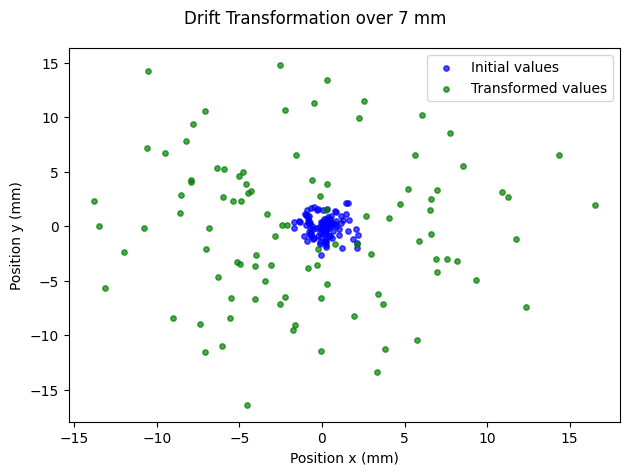

[np.float64(-0.47113595518706), np.float64(6.951255919577753), np.float64(-13.15099944103855), np.float64(-10.794149984868252), np.float64(0.2320754034438799), np.float64(12.364240679333168), np.float64(-13.508827272153674), np.float64(-2.223374151513262), np.float64(-11.997662797970676), np.float64(7.549960356309341), np.float64(-1.7787870744920098), np.float64(6.952720163663836), np.float64(10.916679551588093), np.float64(-13.821221625670749), np.float64(-4.320792907984943), np.float64(6.877592483078265), np.float64(2.1235071823238014), np.float64(-5.958655401078102), np.float64(-0.26357101964040613), np.float64(1.918470431554165), np.float64(-5.574680236520125), np.float64(-4.954620432350092), np.float64(2.252843300720166), np.float64(-7.802532997668017), np.float64(5.732642896689597), np.float64(2.675630316824706), np.float64(5.1826049575272695), np.float64(-4.586180649454569), np.float64(-5.521541266505298), np.float64(6.066973542582186), np.float64(-5.3744355471489715), np.float6

In [38]:
N=100
np.random.seed(42)
values=np.random.randn(N,6)
length=7

d1=draw_beamline()
x_tr1,y_tr1=d1.driftTransformScatter(values, length)
print(x_tr1,y_tr1)

In [39]:
# after
class draw_beamline:
    ...
    def driftTransformScatter(self, values, length, plot = True):
        '''
        Simulates particles passing through drift space

        Parameters
        ----------
        values: np.array(list[float][float])
            2D numPy list of particle elements
        length: float
            length of the drift space particle passes through
        plot: bool, optional
            tells function whether to plot particle data or not

        Returns
        -------
        x_transform: list[float]
            list containing each particles' x position
        y_transform: list[float]
            list containing each particles' y position
        '''


        v = torch.as_tensor(values, dtype=torch.float32)
        l = torch.as_tensor(length, dtype=torch.float32)


        x_pos, phase_x = v[:, 0], v[:, 1]
        y_pos, phase_y = v[:, 2], v[:, 3]


        x_transform = x_pos + l * phase_x
        y_transform = y_pos + l * phase_y


        if plot:

            x_p_np = x_pos.cpu().numpy()
            y_p_np = y_pos.cpu().numpy()
            x_t_np = x_transform.cpu().numpy()
            y_t_np = y_transform.cpu().numpy()

            fig, ax = plt.subplots(figsize=(8, 6))
            ax.scatter(x_p_np, y_p_np, c='blue', s=5, alpha=0.5, label="Initial values")
            ax.scatter(x_t_np, y_t_np, c='green', s=5, alpha=0.5, label="Transformed values")

            ax.set_xlabel('Position x (mm)')
            ax.set_ylabel('Position y (mm)')
            ax.legend(loc='upper right')
            plt.suptitle(f"Drift Transformation (Vectorized) over {length} mm")
            plt.tight_layout()
            plt.show()

        return x_transform, y_transform

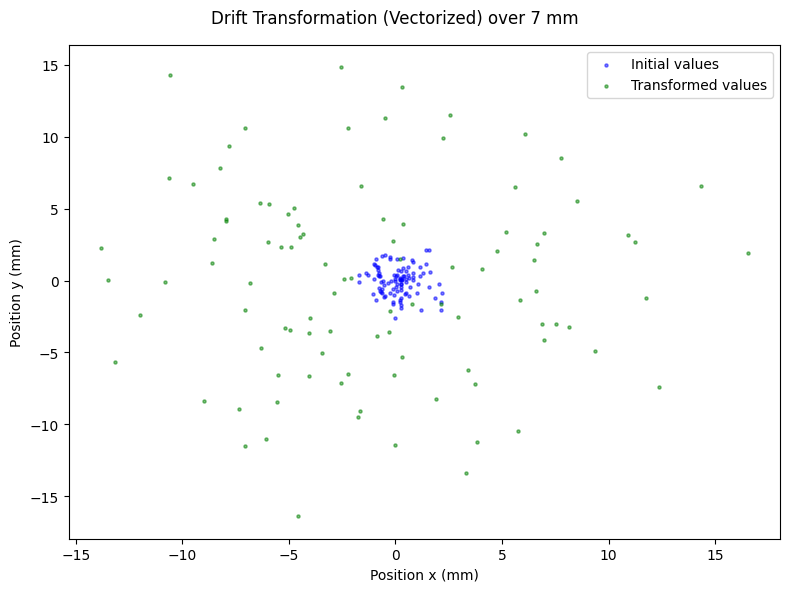

tensor([ -0.4711,   6.9513, -13.1510, -10.7941,   0.2321,  12.3642, -13.5088,
         -2.2234, -11.9977,   7.5500,  -1.7788,   6.9527,  10.9167, -13.8212,
         -4.3208,   6.8776,   2.1235,  -5.9587,  -0.2636,   1.9185,  -5.5747,
         -4.9546,   2.2528,  -7.8025,   5.7326,   2.6756,   5.1826,  -4.5862,
         -5.5215,   6.0670,  -5.3744,  -0.0366,  -8.5061,  -7.9426,  -7.9424,
          8.5198,  -2.4306, -10.6028,   4.0419,   6.5814,  -1.5957,  -5.0483,
          9.3494,   5.8663,  -8.9871,  -8.6098,  -4.0025,  -7.0787,  -4.0779,
         -4.4934,  -4.7503,  -2.8633,   6.5200,  -0.5868,  -9.5053,  -6.2930,
         -3.0752,  -3.3036,  -2.2126,  -7.0367,  11.2485,   0.3122,   8.1660,
         -3.4683,   0.2936,   2.5450,   7.7640,   0.3341,   3.7214,  -4.9071,
         14.3481,   3.8374,   4.7534,  -2.0922,   3.3832,   6.6233,  -7.3537,
          0.7981,  -4.5612,  -0.0983,  -6.8167,  -8.2174,  -5.9516, -10.5552,
         -4.0605,  -0.0812,  -6.3420,   3.3316,  -6.0705,  -0.32

In [40]:
N=100
np.random.seed(42)
values=np.random.randn(N,6)
values=torch.as_tensor(values, dtype=torch.float32)
length=7

d1=draw_beamline()
x_tr2,y_tr2=d1.driftTransformScatter(values, length)
print(x_tr2,y_tr2)

In [41]:
print(np.allclose(x_tr1,x_tr2))
print(np.allclose(y_tr1,y_tr2))

True
True


## draw_beamline > checkMinMax

In [42]:
# before
class draw_beamline:
    ...
    def checkMinMax(self, matrixVariables, maxval, minval):
        '''
        Updates max and min values of a set of particles in a beamline. Used for finding and
        setting the plot boundaries displaying the position of particles.

        Parameters
        ----------
        matrixvairables: np.array(list[float][float])
            A 6 column 2d numpy array, each row containing 6 initial values of each particle's measurements
        maxval: list[float]
            list of each current maximum value for each variable throughout the beamline
        minval: list[float]
            list of each current minimum value for each variable throughout the beamline

        Returns
        -------
        maxval: list[float]
            updated list of maximum values
        minval: list[float]
            updated list of minimum values
        '''
        initialx = matrixVariables[:, 0]
        initialy = matrixVariables[:, 2]
        initialxphase = matrixVariables[:, 1]
        initialyphase = matrixVariables[:, 3]
        initialz = matrixVariables[:, 4]
        initialzphase = matrixVariables[:, 5]
        initialList = [initialx, initialxphase, initialy, initialyphase, initialz, initialzphase]
        for i in range(len(initialList)):
            maximum = max(initialList[i])
            if maximum > maxval[i]:
                maxval[i] = maximum
            minimum = min(initialList[i])
            if minimum < minval[i]:
                minval[i] = minimum
        return maxval, minval

In [43]:
N=100
np.random.seed(42)
matrixVariables=np.random.randn(N,6)
minval=[np.inf]*6
maxval=[-np.inf]*6
d1=draw_beamline()
updated_max1, updated_min1 = d1.checkMinMax(matrixVariables, maxval, minval)
print(updated_max1, updated_min1)

[np.float64(2.1898029332176723), np.float64(2.270692857804396), np.float64(2.1531824575115563), np.float64(2.075400798645439), np.float64(3.0788808084552377), np.float64(3.852731490654721)] [np.float64(-1.7131345290908775), np.float64(-1.9875689146008928), np.float64(-2.6197451040897444), np.float64(-2.301921164735585), np.float64(-3.2412673400690726), np.float64(-2.211135309007885)]


In [44]:
# after
class draw_beamline:
    ...
    def checkMinMax(self, matrixVariables, maxval, minval):
        '''
        Updates max and min values of a set of particles in a beamline. Used for finding and
        setting the plot boundaries displaying the position of particles.

        Parameters
        ----------
        matrixvairables: np.array(list[float][float])
            A 6 column 2d numpy array, each row containing 6 initial values of each particle's measurements
        maxval: list[float]
            list of each current maximum value for each variable throughout the beamline
        minval: list[float]
            list of each current minimum value for each variable throughout the beamline

        Returns
        -------
        maxval: list[float]
            updated list of maximum values
        minval: list[float]
            updated list of minimum values
        '''
        matrixVariables=torch.tensor(matrixVariables, dtype=torch.float32)
        list_max=torch.max(matrixVariables, dim=0).values
        list_min=torch.min(matrixVariables, dim=0).values

        updated_max=torch.maximum(list_max, torch.tensor(maxval,dtype=torch.float32))
        updated_min=torch.minimum(list_min, torch.tensor(minval,dtype=torch.float32))

        return updated_max.cpu().numpy().tolist(), updated_min.cpu().numpy().tolist()

In [45]:
N=100
np.random.seed(42)
matrixVariables=np.random.randn(N,6)
minval=[np.inf]*6
maxval=[-np.inf]*6
d1=draw_beamline()
updated_max2, updated_min2 = d1.checkMinMax(matrixVariables, maxval, minval)
print(updated_max2, updated_min2)

[2.189802885055542, 2.270692825317383, 2.1531825065612793, 2.0754008293151855, 3.078880786895752, 3.852731466293335] [-1.713134527206421, -1.9875688552856445, -2.6197450160980225, -2.3019211292266846, -3.241267442703247, -2.2111353874206543]


In [46]:
print(np.allclose(updated_min1, updated_min2))
print(np.allclose(updated_max1, updated_max2))

True
True
